In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import ROOT
mpl.rc('text', usetex = True)

In [3]:
# Only limited to spin-1 so can have it be a bit hardcodey
# Changing from root branch name to wave format
# i.e. a_T_1_0 = P^+_{T0}
def ToWave(x):
   tmp = x.split('_')
   refl = "+"
   pol = tmp[1]
   wave = "S"
   m = "0"

   if (tmp[0] == 'b'):
       refl = "-"
   if (tmp[2] == '1'):
       wave = "P"
   if (tmp[3] == '1'):
       m = "1"
   elif (tmp[3] == 'm1'):
       m = "-1"

   return wave+"$^"+refl+"_{\\mathrm{" +pol + "}" + m + "}$"

In [4]:
def circular_mean(phi):
    return np.angle(np.mean(np.exp(1j * phi)))

def circular_std(phi):
    R = np.abs(np.mean(np.exp(1j * phi)))
    return np.sqrt(-2 * np.log(R))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

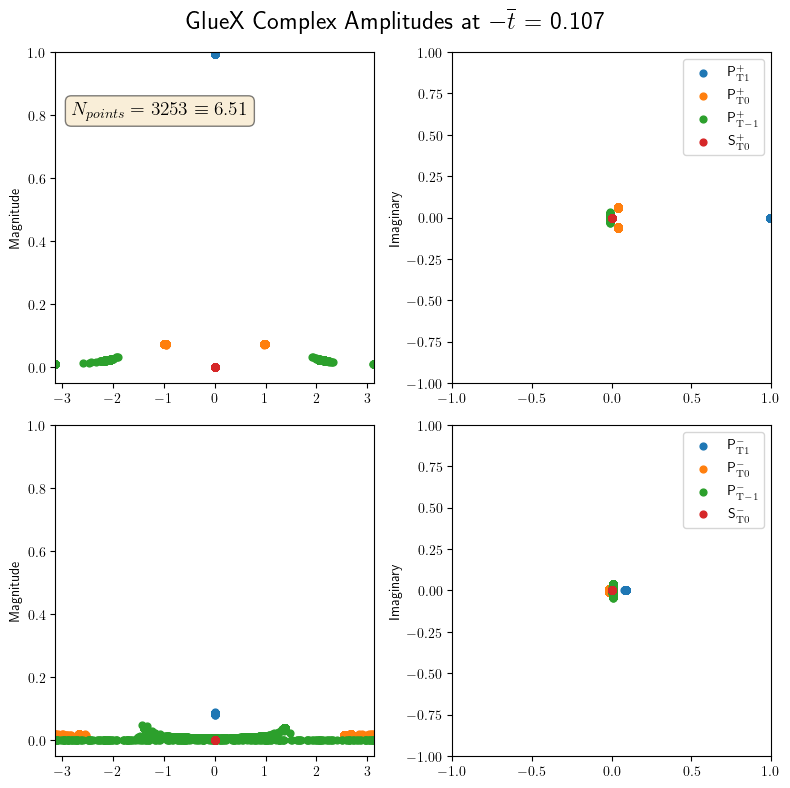

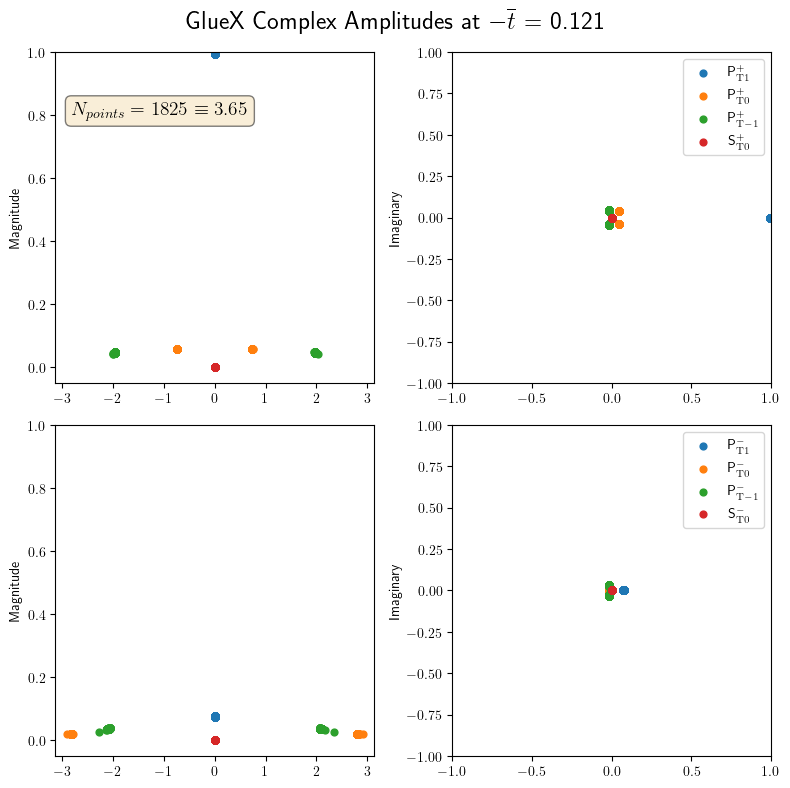

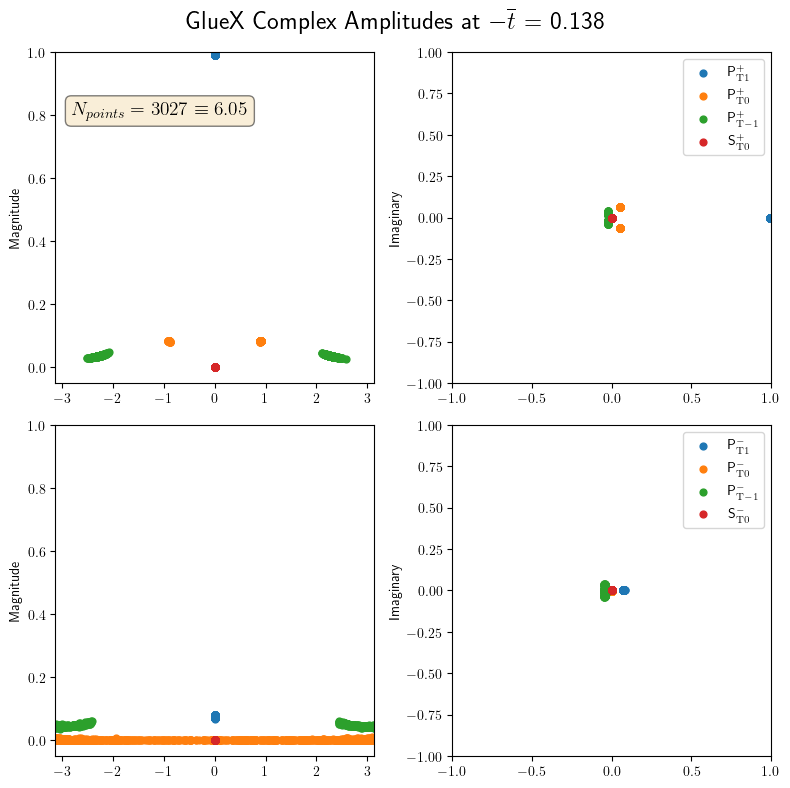

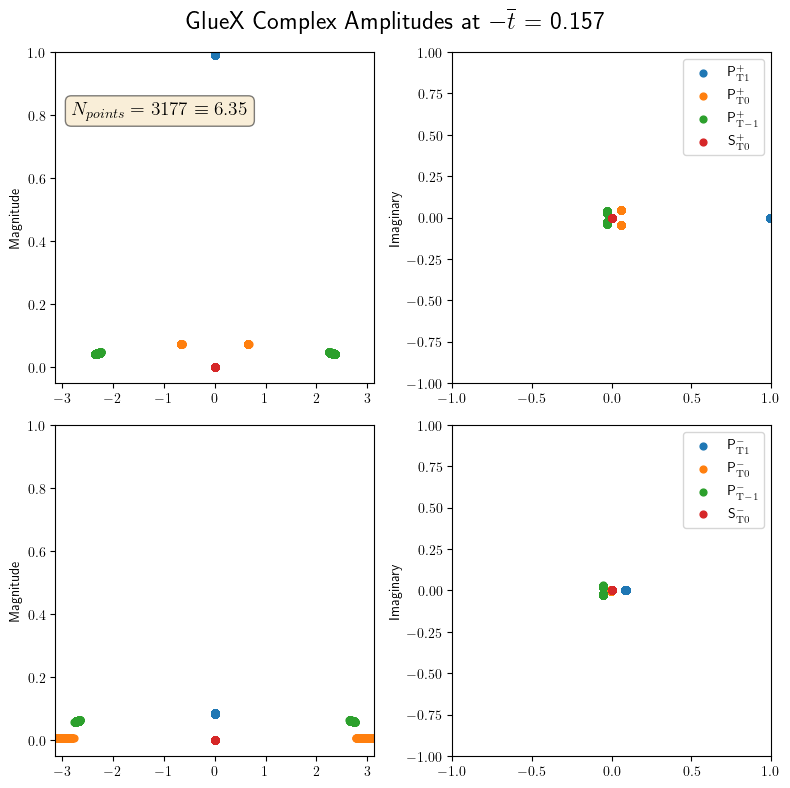

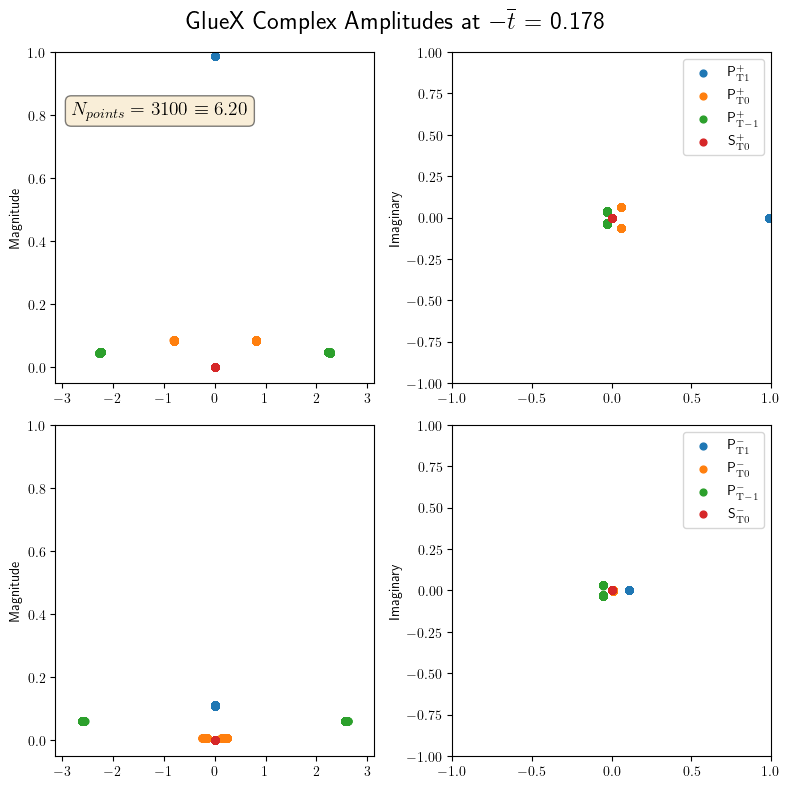

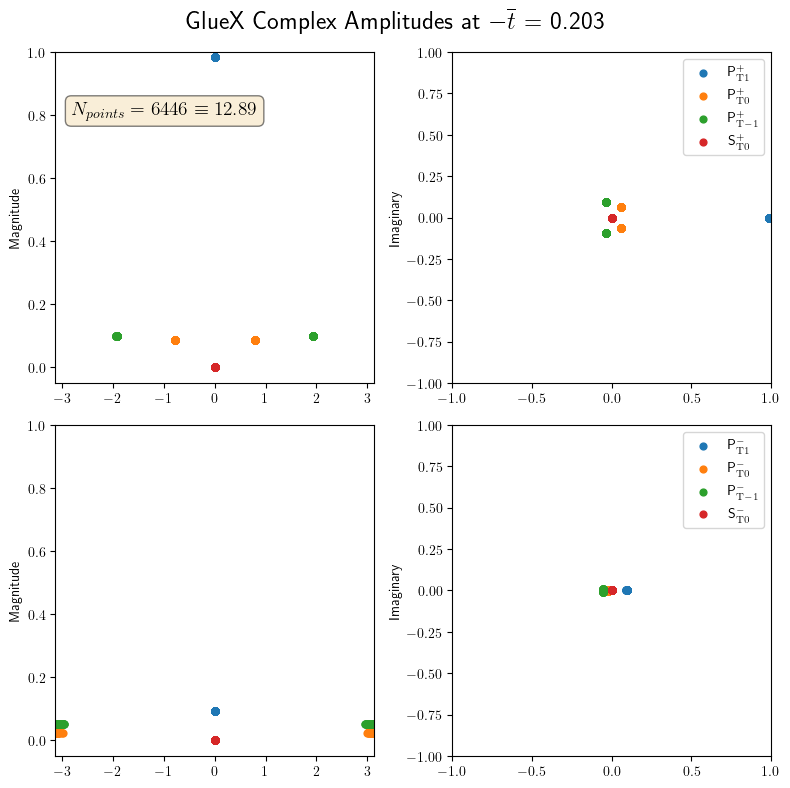

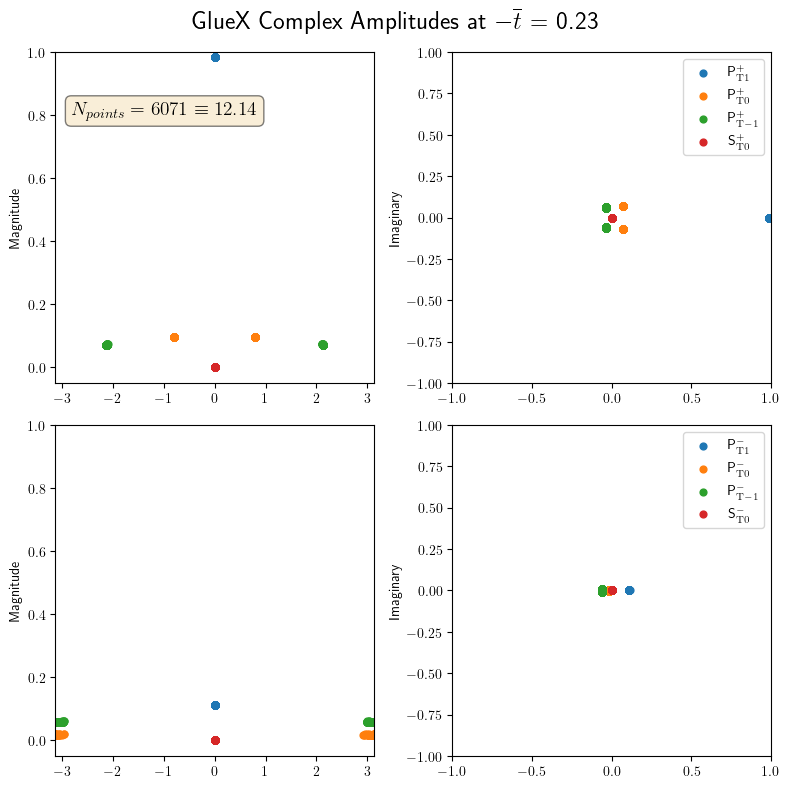

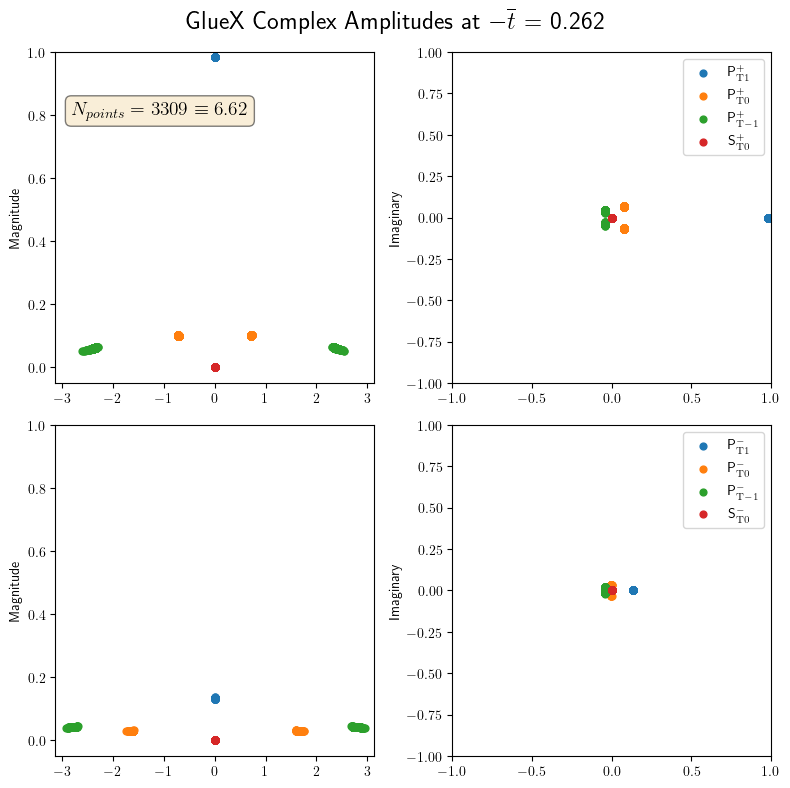

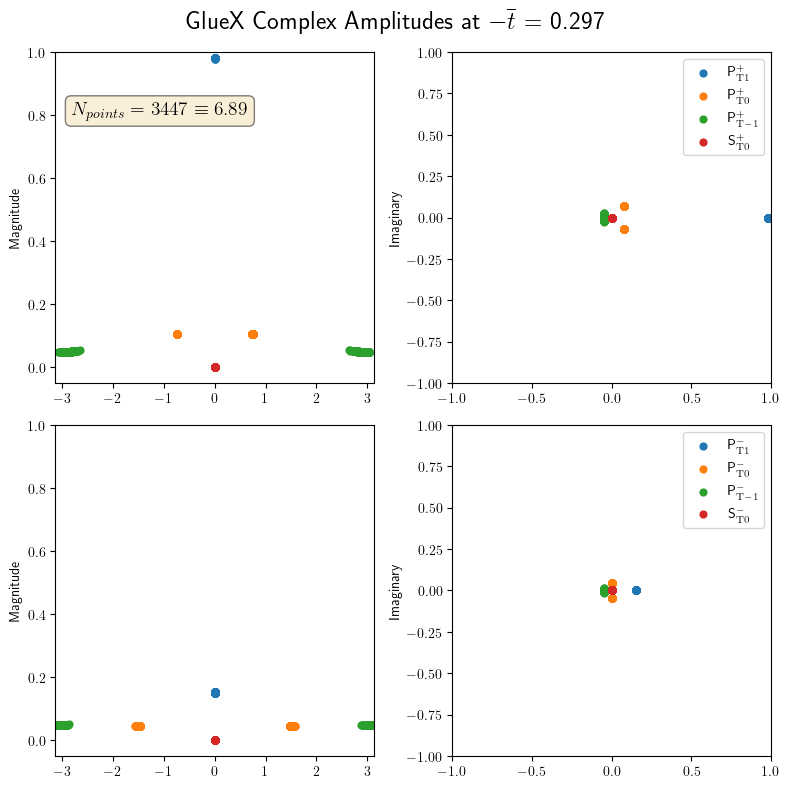

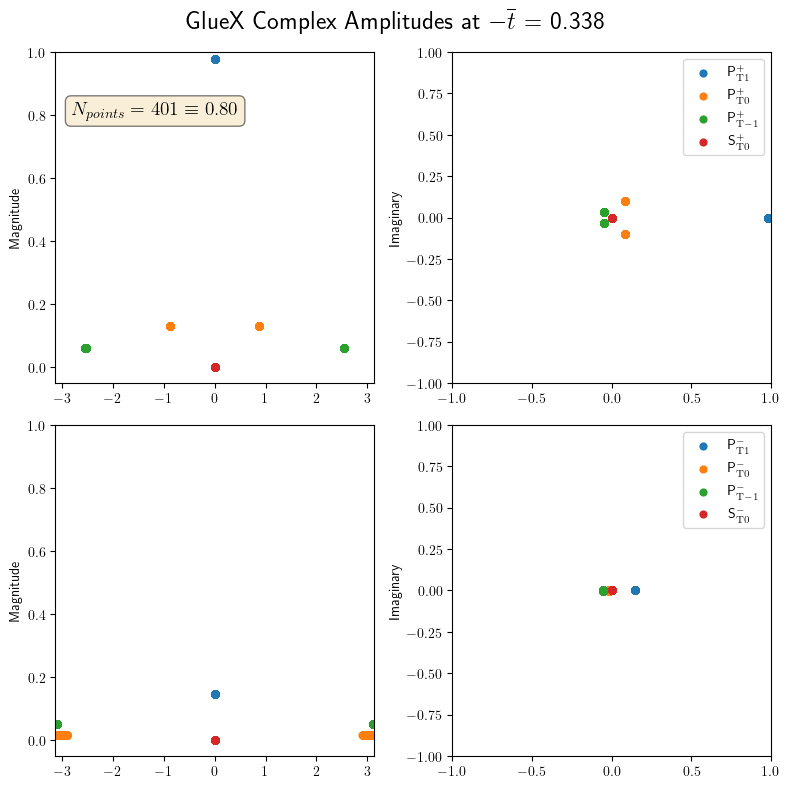

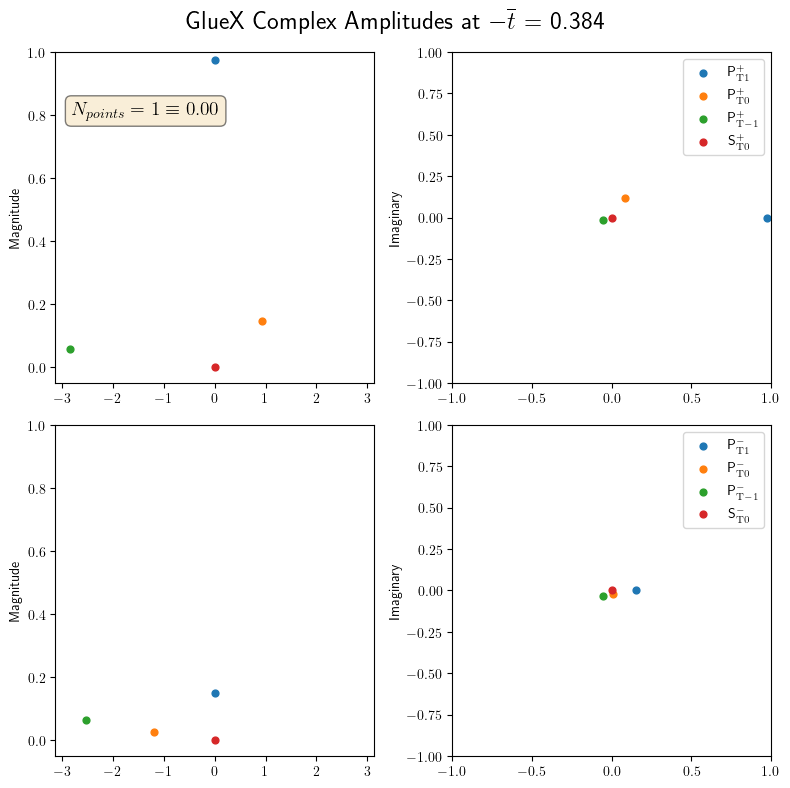

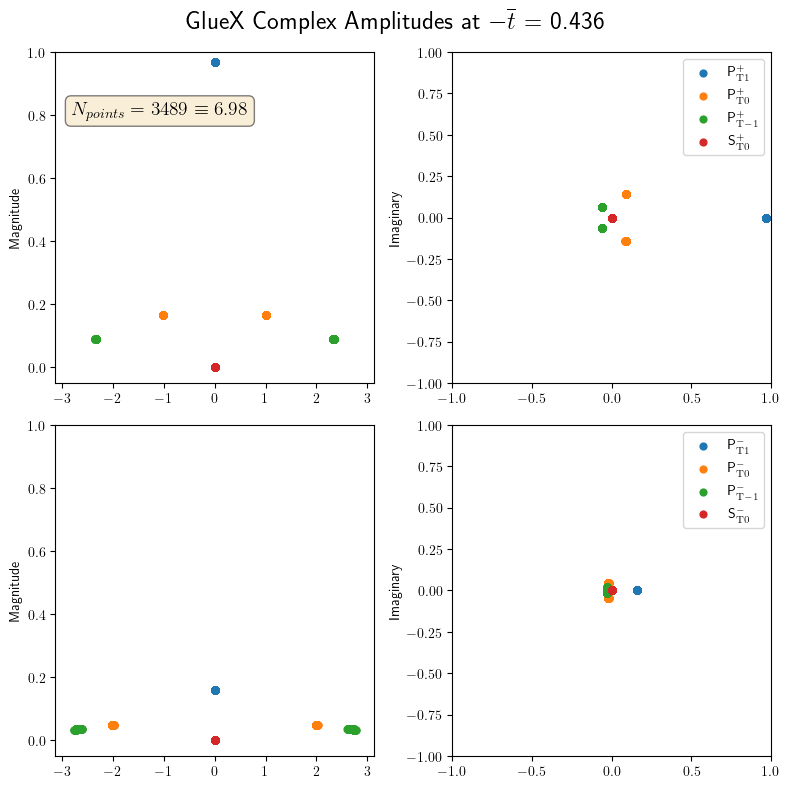

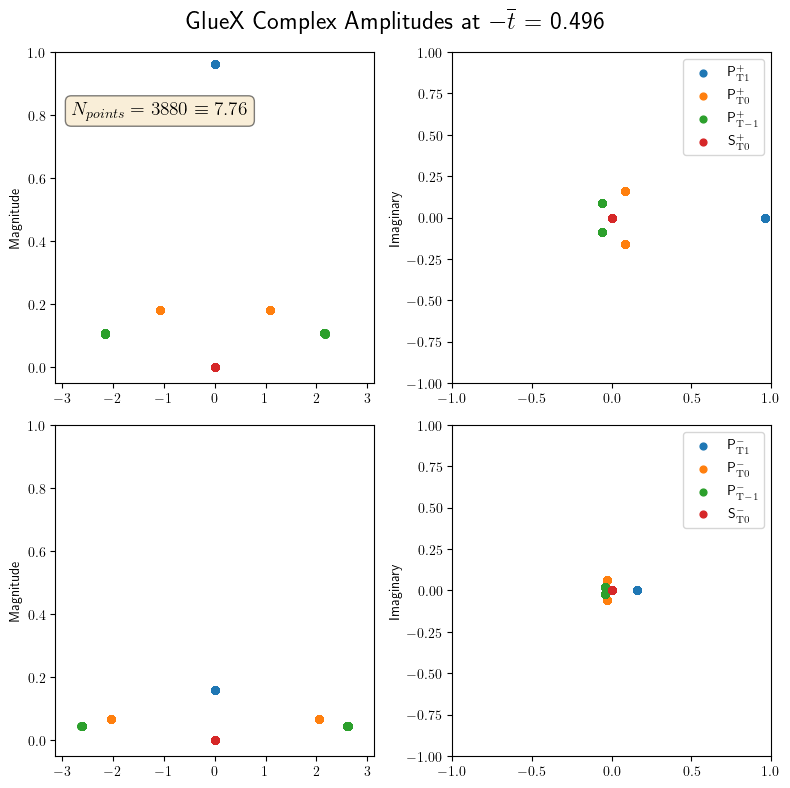

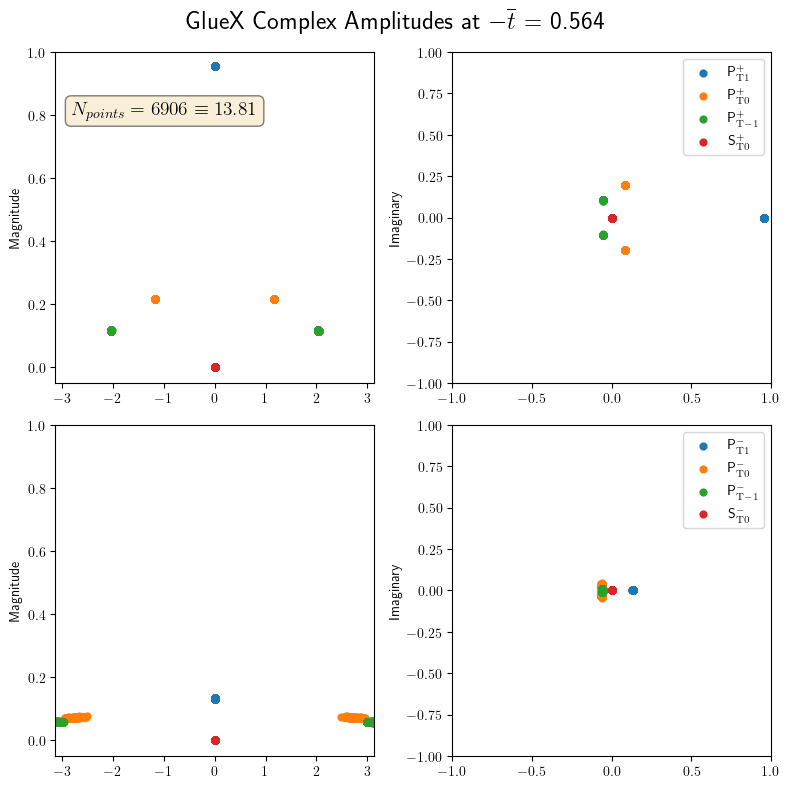

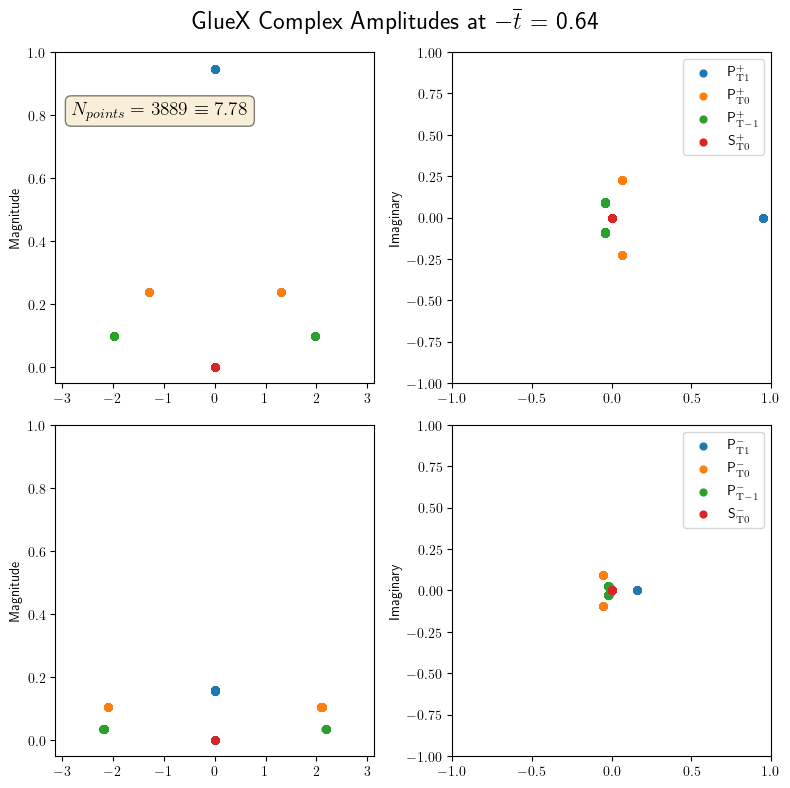

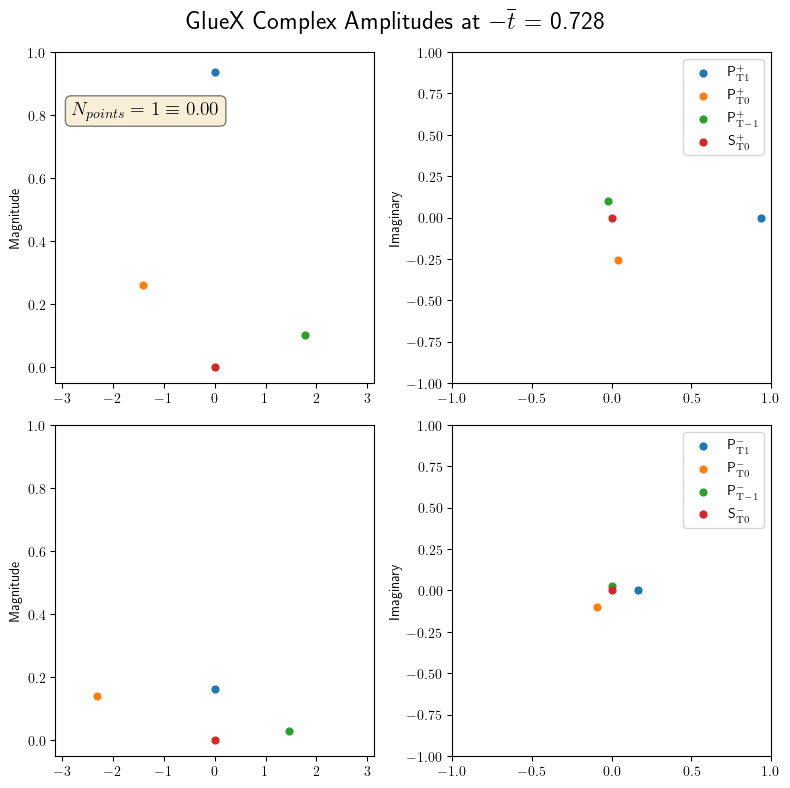

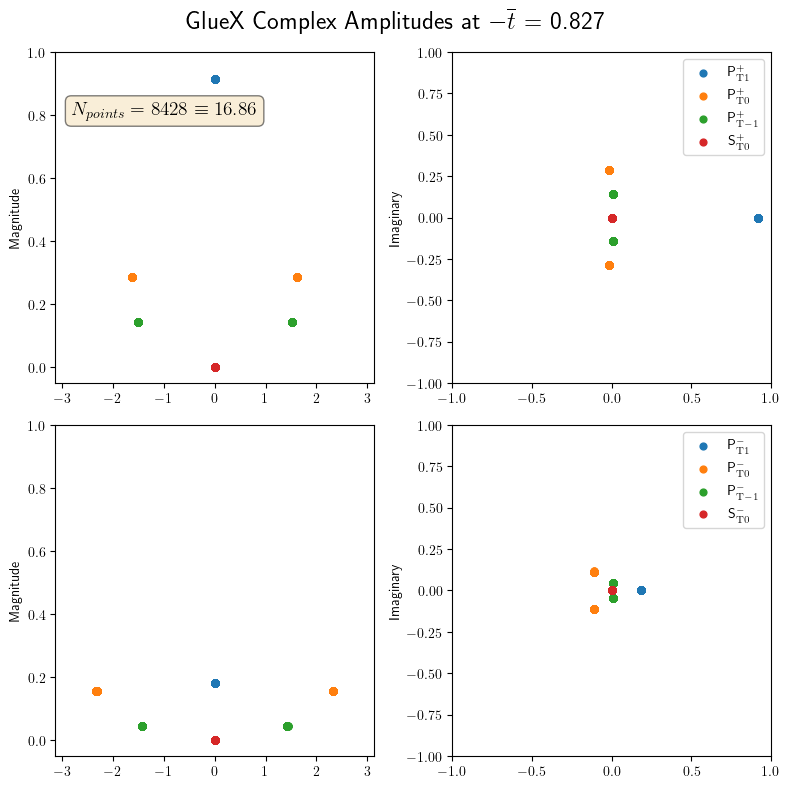

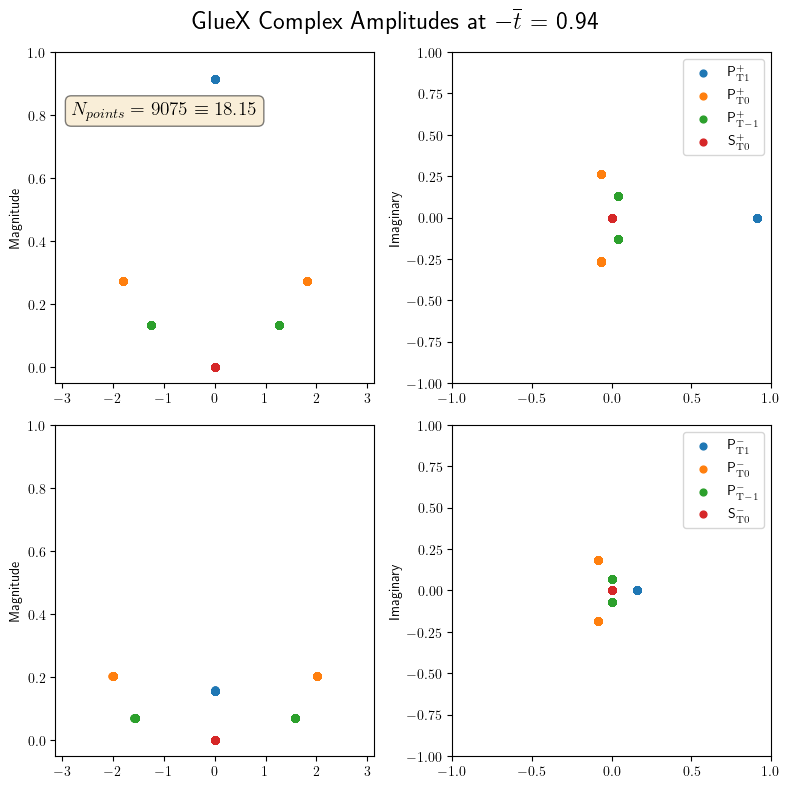

In [5]:
# DataFrame column names
cols_mag = ["a_T_1_1", "a_T_1_0", "a_T_1_m1", "a_T_0_0",
        "b_T_1_1", "b_T_1_0", "b_T_1_m1", "b_T_0_0",
        "a_L_1_1", "a_L_1_0", "a_L_1_m1", "a_L_0_0",
        "b_L_1_1", "b_L_1_0", "b_L_1_m1", "b_L_0_0"]

cols_phase = ["aphi_T_1_1", "aphi_T_1_0", "aphi_T_1_m1", "aphi_T_0_0",
        "bphi_T_1_1", "bphi_T_1_0", "bphi_T_1_m1", "bphi_T_0_0",
        "aphi_L_1_1", "aphi_L_1_0", "aphi_L_1_m1", "aphi_L_0_0",
        "bphi_L_1_1", "bphi_L_1_0", "bphi_L_1_m1", "bphi_L_0_0"]

t = np.array([
    0.107, 0.121, 0.138, 0.157, 0.178, 0.203,
    0.230, 0.262, 0.297, 0.338, 0.384, 0.436,
    0.496, 0.564, 0.640, 0.728, 0.827, 0.940
])

mags_array = np.empty((18,4,4))
phases_array = np.empty((18,4,4))

# For HERMEs data they are saved this way (4 Q2 bins)
for i in range(18):
    df = ROOT.RDataFrame("fitResults", "~/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles/gluex_results_"+str(i)+".root")

    min_log = df.Min("log_val").GetValue()
    df = df.Filter("log_val<="+str(min_log + 0.01))

    arrays_mag = df.AsNumpy(columns=cols_mag)
    arrays_phase = df.AsNumpy(columns=cols_phase)

    # All arrays have the same length
    N = np.shape(arrays_mag[cols_mag[0]])[0]

    fig = plt.figure(figsize=(8,8))
    axs = fig.subplots(2,2)
    pcent = 100*N/50_000
    axs[0,0].text(0.05, 0.85, "$N_{{points}} ={0}\\equiv {1:.2f}$".format(N, pcent), fontsize=14,
        verticalalignment='top', transform=axs[0,0].transAxes, bbox=props)
    for j in range(2):
        #The main plotting
        for k in range(4):
            y = arrays_mag[cols_mag[k + 4*j]]
            x = arrays_phase[cols_phase[k + 4*j]]

            re = y*np.cos(x)
            im = y*np.sin(x)

            axs[j,0].scatter(x,y, s=24)
            axs[j,0].axis(xmin=-np.pi, xmax = np.pi, ymin = -0.05, ymax = 1)

            axs[j,1].scatter(re,im, s=24, label=ToWave(cols_mag[k + 4*j]))
            axs[j,1].axis(xmin=-1, xmax = 1, ymin = -1, ymax = 1)

            axs[j,0].set_ylabel("Magnitude")
            axs[j,1].set_ylabel("Imaginary")
            if (j==3):
                axs[j,0].set_xlabel("Phase")
                axs[j,1].set_xlabel("Real")


            axs[j,1].legend()
        # Maybe have an overall title giving more information?
    fig.suptitle("GlueX Complex Amplitudes at $-\\overline t$ = {0}".format(t[i]), size=18)
    fig.tight_layout()
    fig.savefig("GlueX_min_"+str(i)+".png", format= 'png')


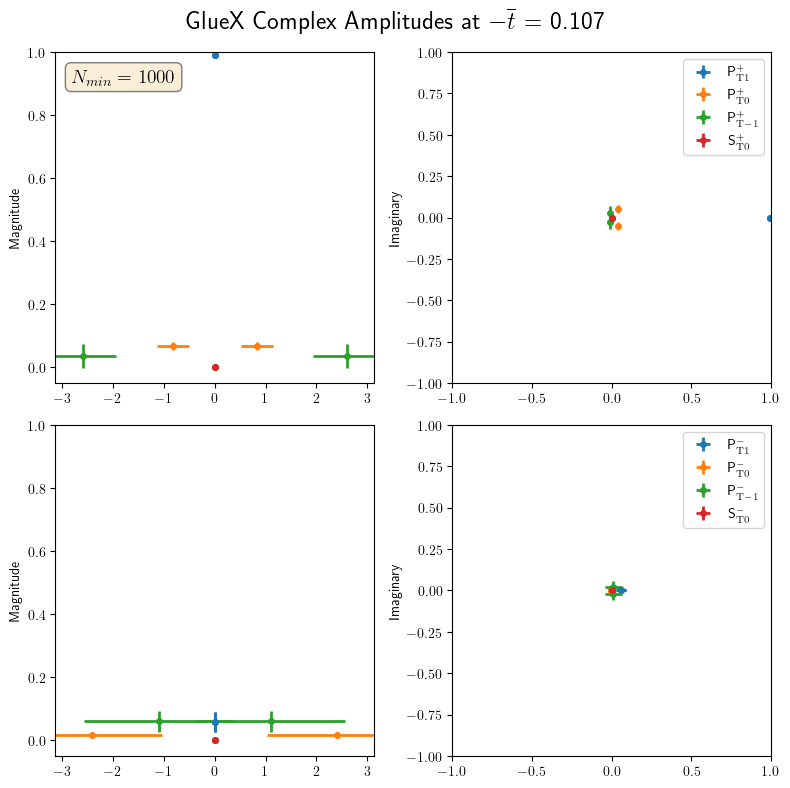

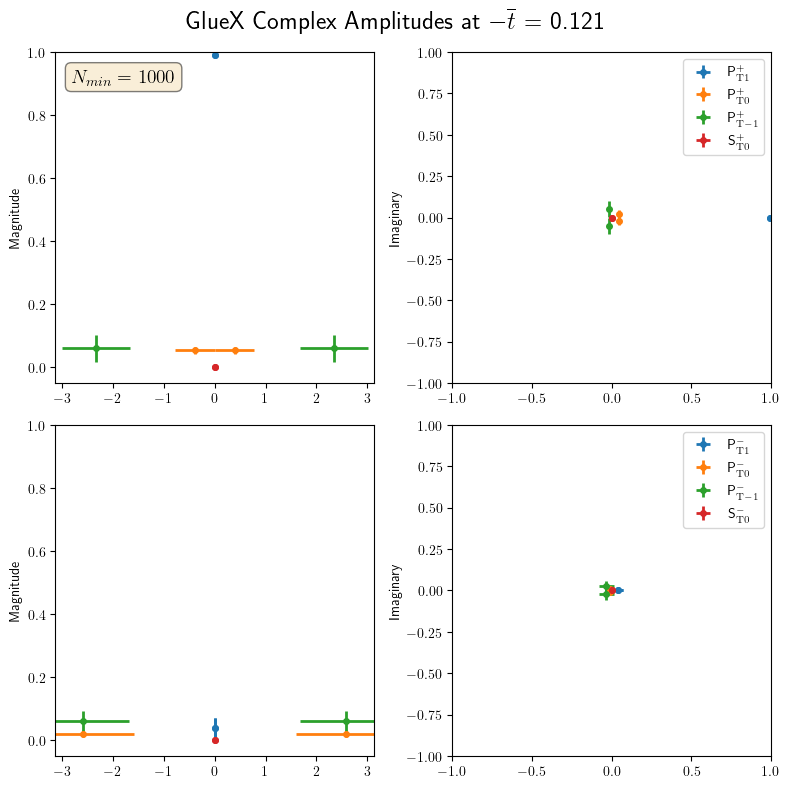

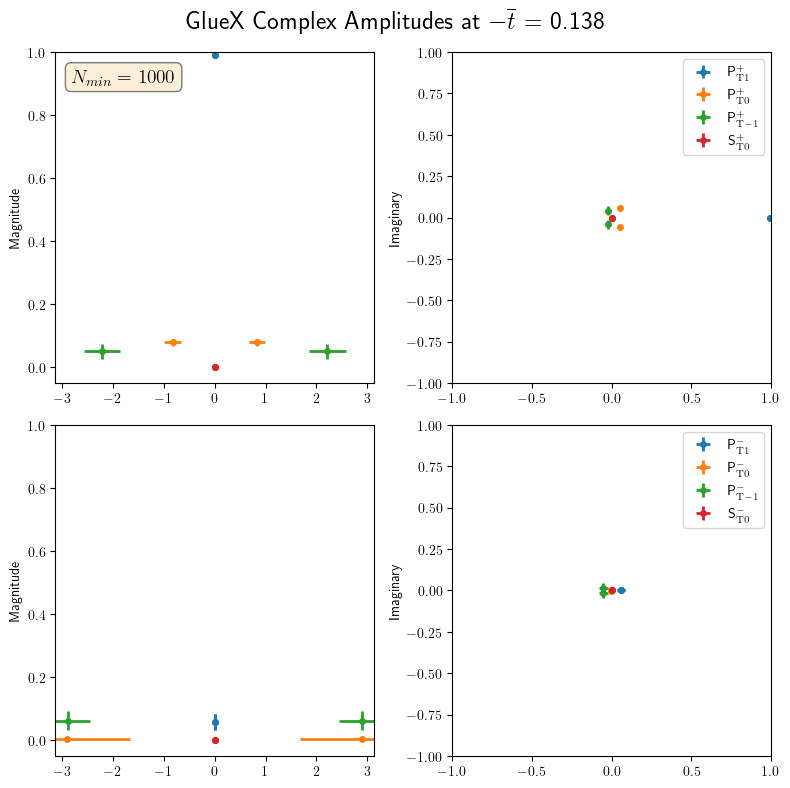

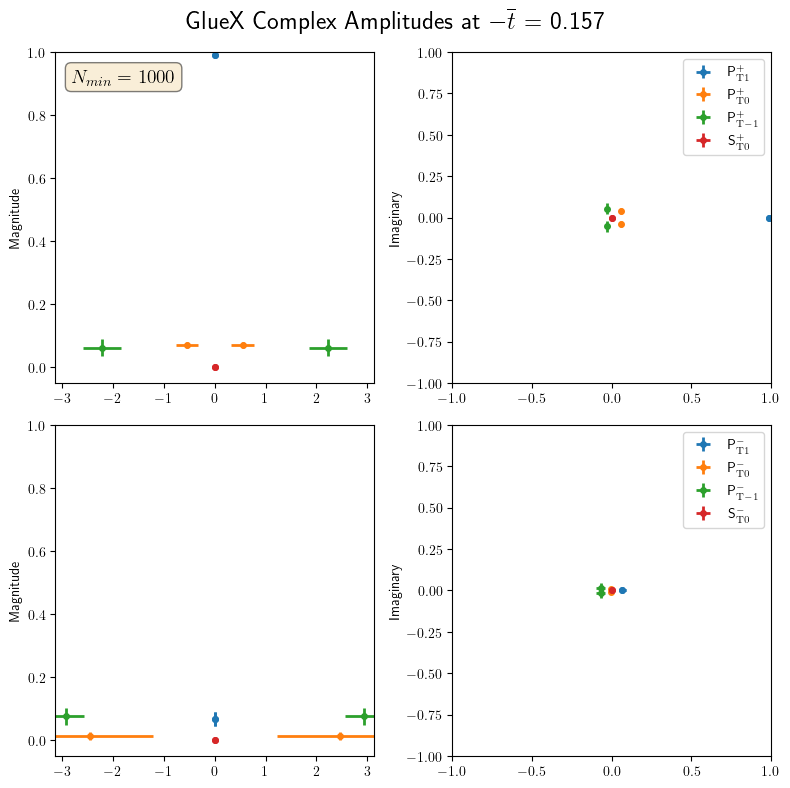

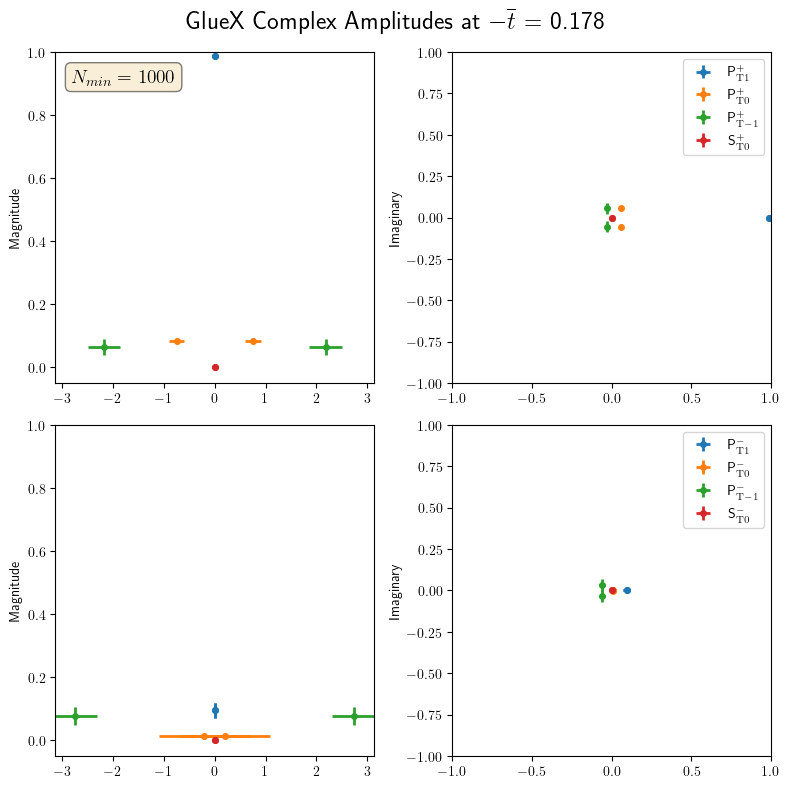

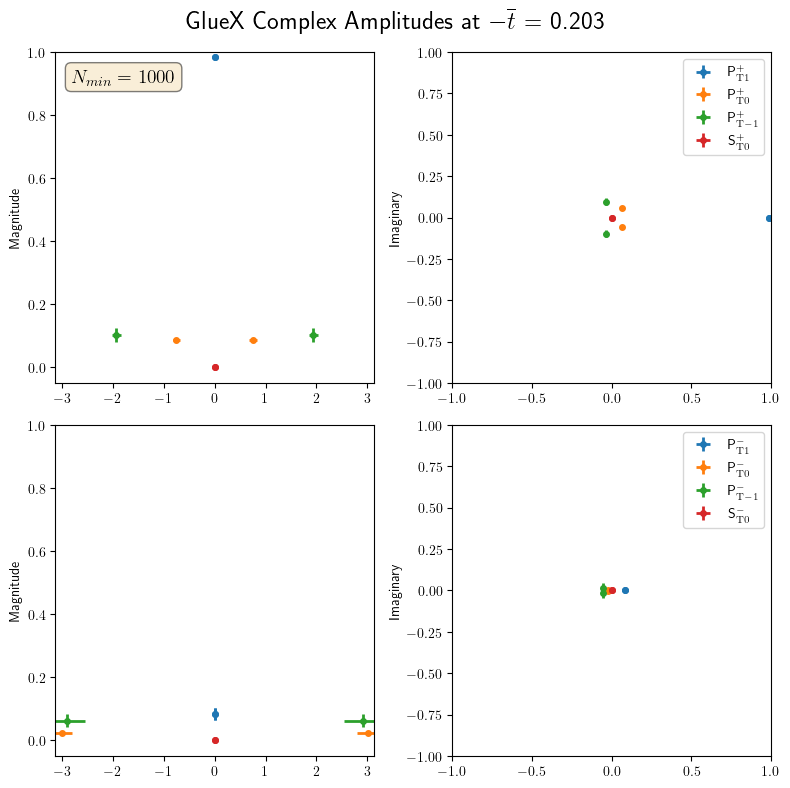

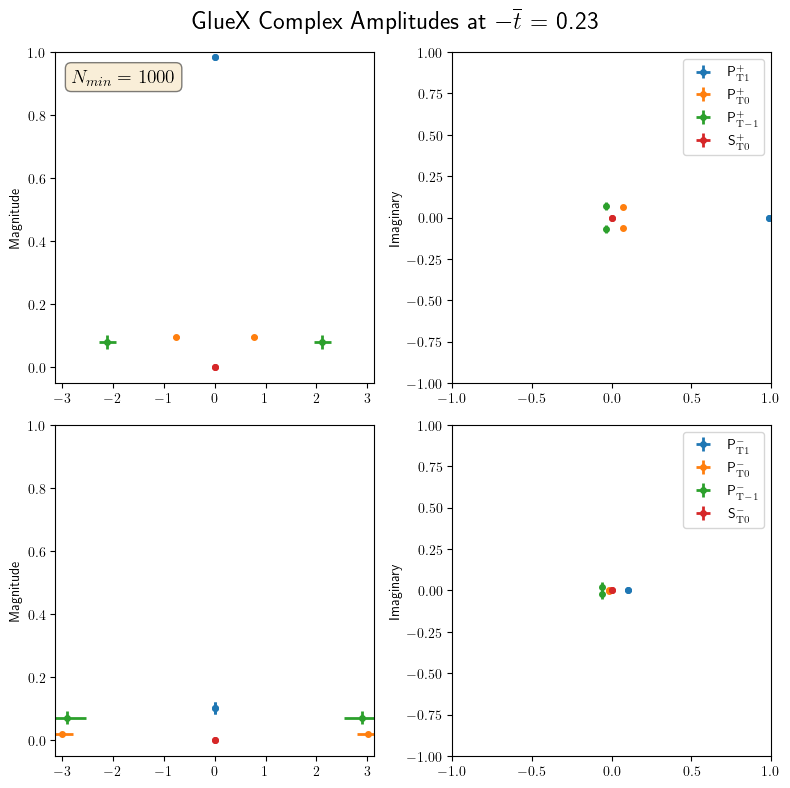

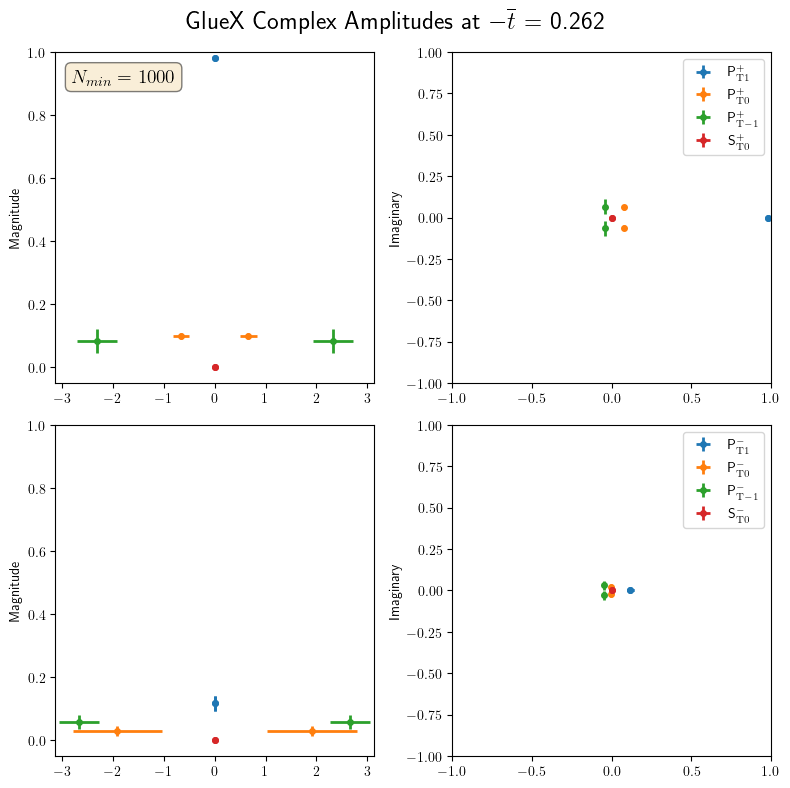

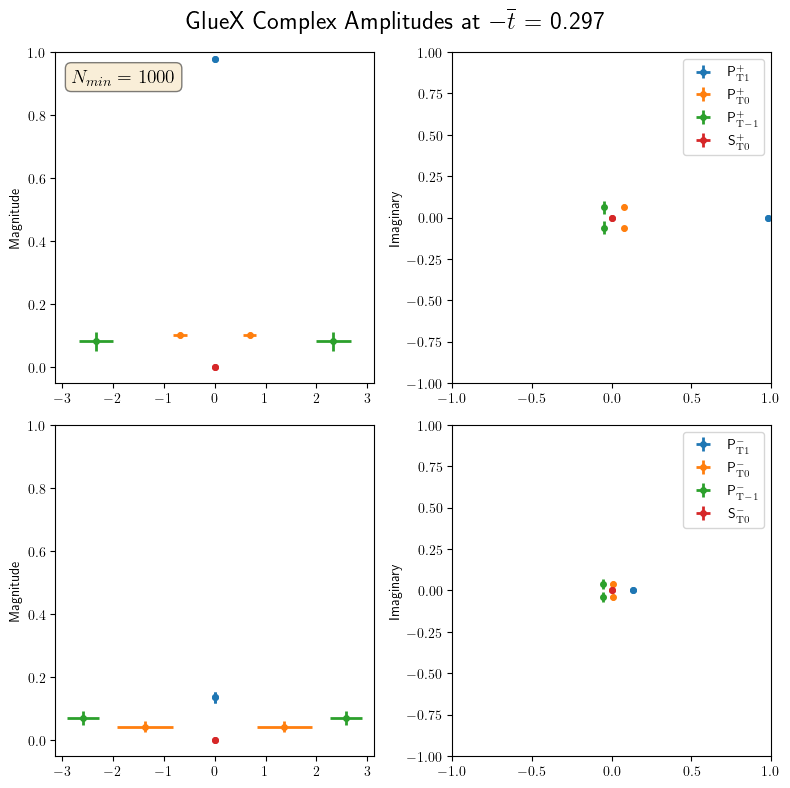

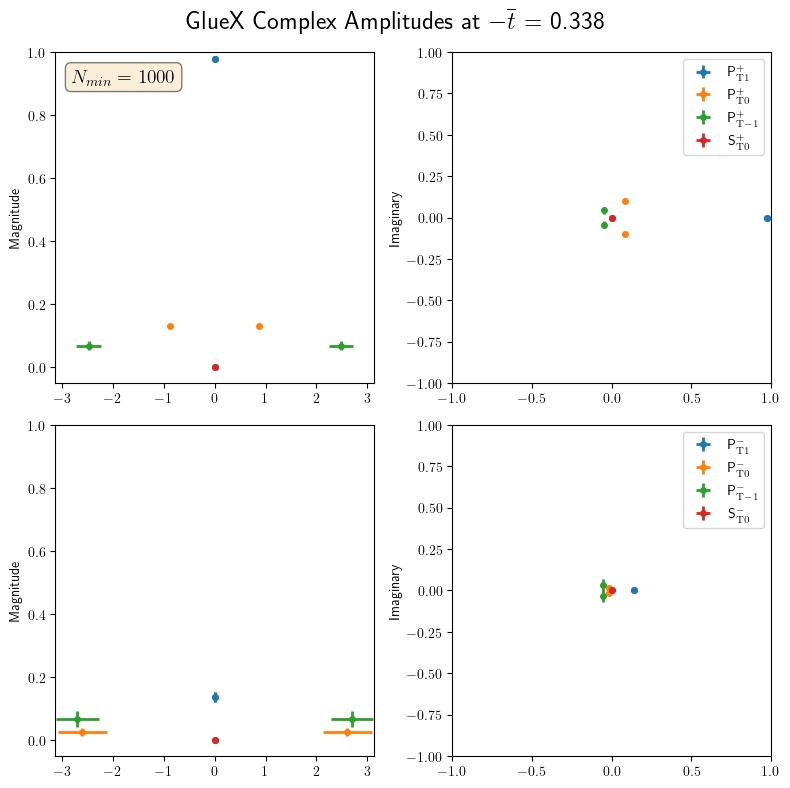

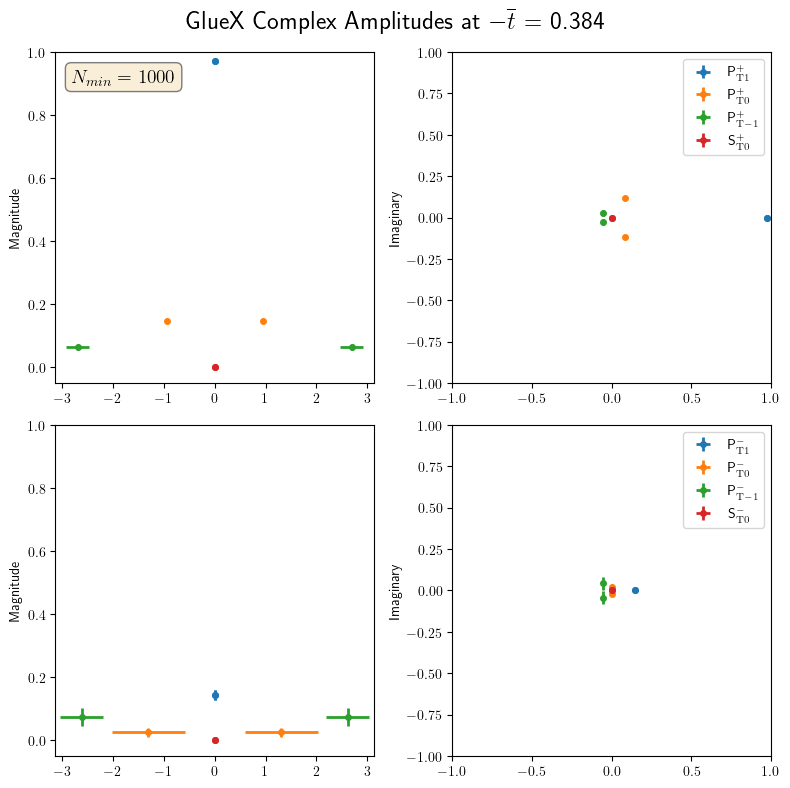

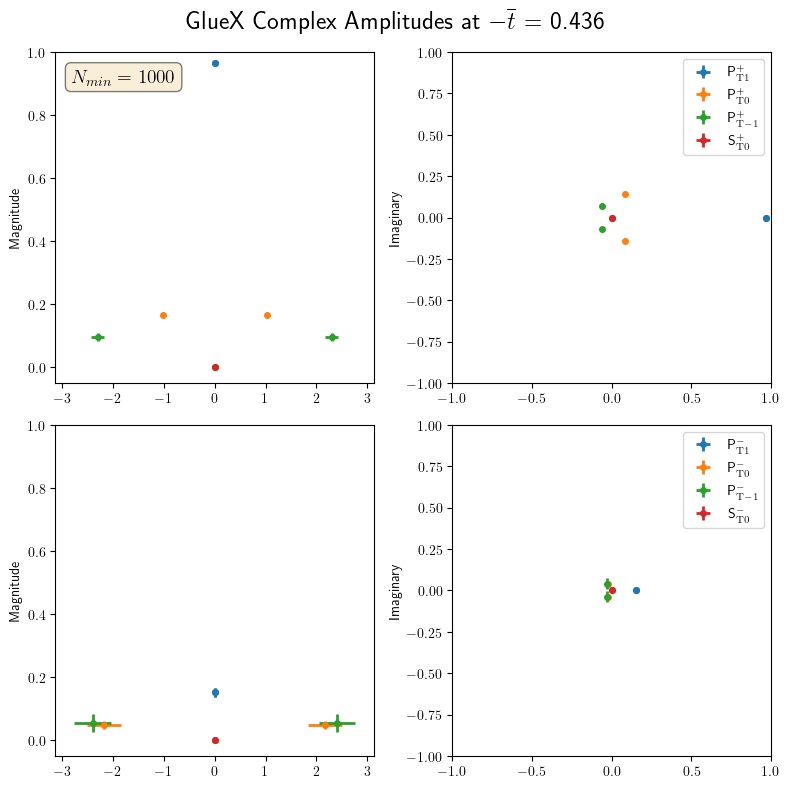

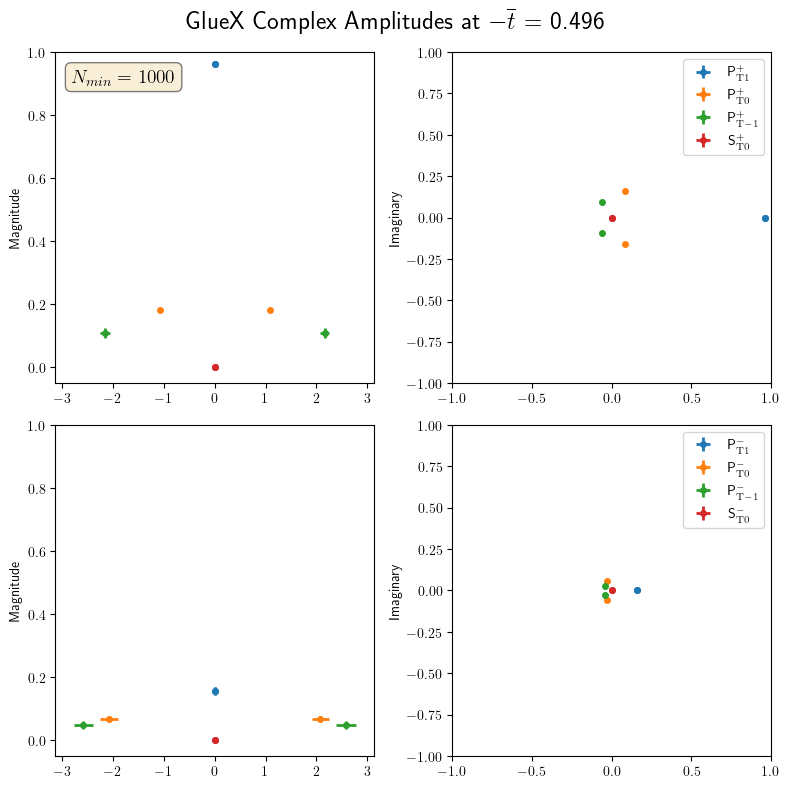

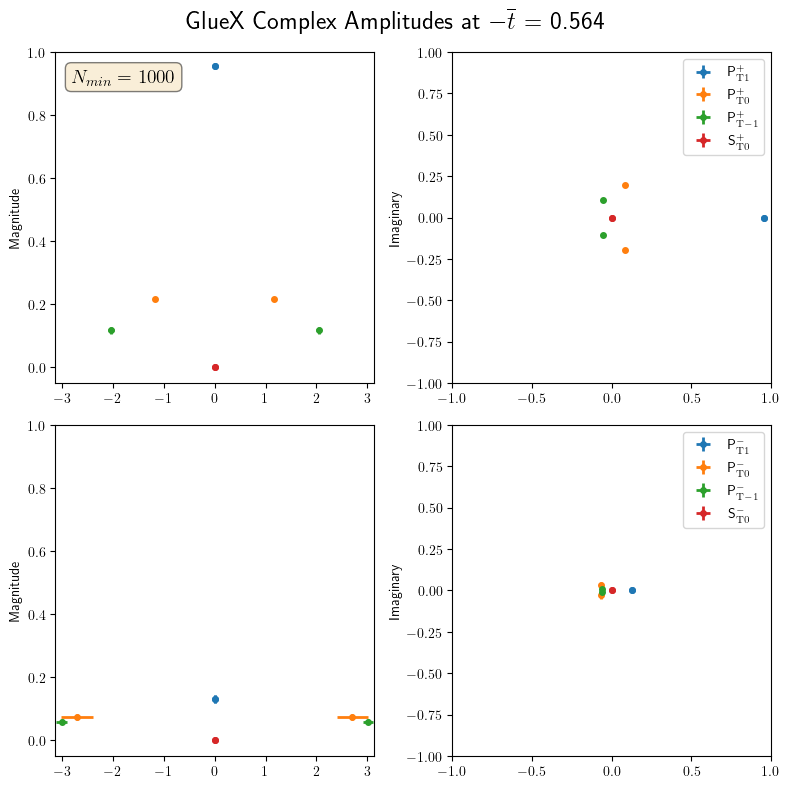

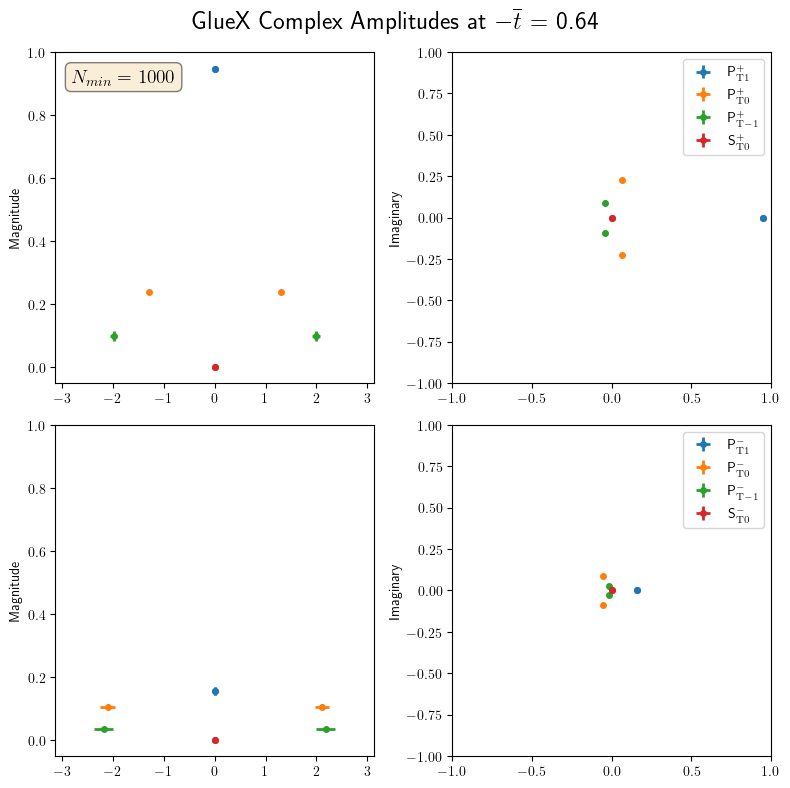

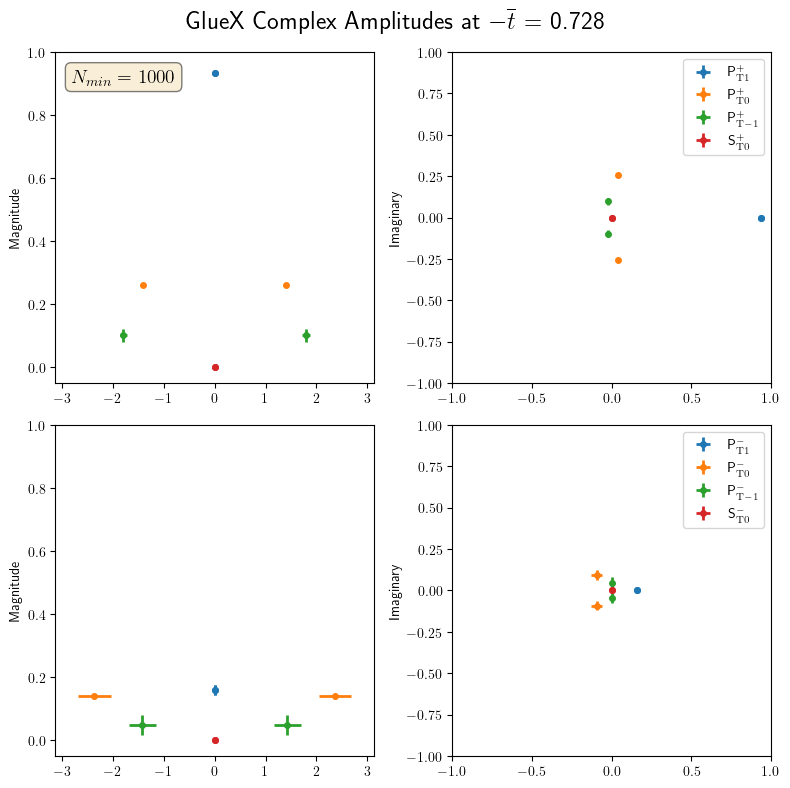

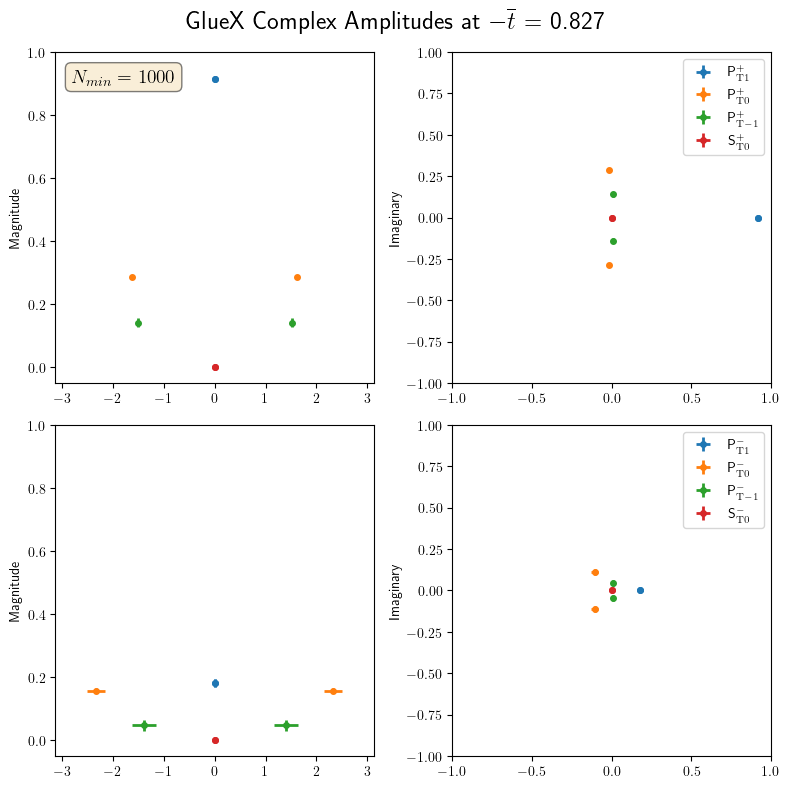

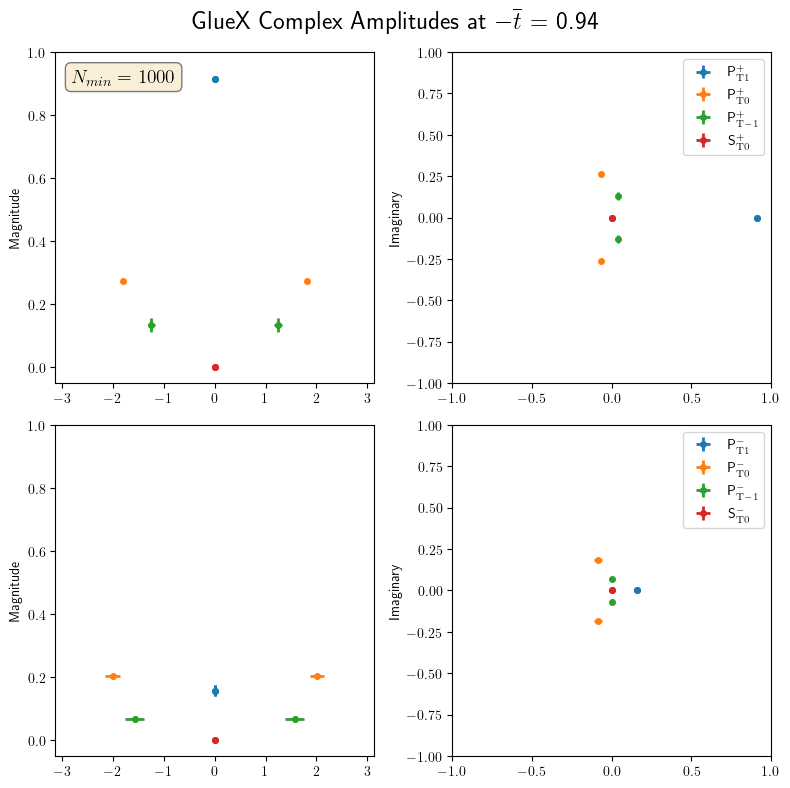

In [13]:
# For HERMEs data they are saved this way (4 Q2 bins)
for i in range(18):
    if i<=4:
        tname = "PartialWaves"
    else:
        tname = "toyFitResults"
    df = ROOT.RDataFrame(tname, "~/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles/gluex_bootstrap_"+str(i)+".root")

    arrays_mag = df.AsNumpy(columns=cols_mag)
    arrays_phase = df.AsNumpy(columns=cols_phase)

    # All arrays have the same length
    N = np.shape(arrays_mag[cols_mag[0]])[0]

    fig = plt.figure(figsize=(8,8))
    axs = fig.subplots(2,2)
    axs[0,0].text(0.05, 0.95, "$N_{{min}} = 1000$", fontsize=14,
        verticalalignment='top', transform=axs[0,0].transAxes, bbox=props)
    for j in range(2):
        #The main plotting
        for k in range(4):
            y = arrays_mag[cols_mag[k + 4*j]]
            x = np.abs(arrays_phase[cols_phase[k + 4*j]])

            re = y*np.cos(x)
            im = y*np.sin(x)

            mean_y = np.mean(y)
            err_y = np.std(y)

            mean_x = circular_mean(x)
            err_x= circular_std(x)

            mean_re = np.mean(re)
            err_re= np.std(re)

            mean_im = np.mean(im)
            err_im = np.std(im)

            p = axs[j,0].errorbar(mean_x,mean_y,xerr=err_x,yerr=err_y, fmt='.', markersize=8, elinewidth=2)
            c = p.lines[0].get_color()
            axs[j,0].errorbar(-mean_x,mean_y,xerr=err_x,yerr=err_y, fmt='.', markersize=8, elinewidth=2, color=c)
            axs[j,0].axis(xmin=-np.pi, xmax = np.pi, ymin = -0.05, ymax = 1)

            axs[j,1].errorbar(mean_re,mean_im,xerr = err_re, yerr = err_im, fmt='.', markersize=8, elinewidth=2, color=c, label=ToWave(cols_mag[k + 4*j]))
            axs[j,1].errorbar(mean_re,-mean_im,xerr = err_re, yerr = err_im, fmt='.', markersize=8, color=c, elinewidth=2)
            axs[j,1].axis(xmin=-1, xmax = 1, ymin = -1, ymax = 1)

            axs[j,0].set_ylabel("Magnitude")
            axs[j,1].set_ylabel("Imaginary")
            if (j==3):
                axs[j,0].set_xlabel("Phase")
                axs[j,1].set_xlabel("Real")


            axs[j,1].legend()
        # Maybe have an overall title giving more information?
    fig.suptitle("GlueX Complex Amplitudes at $-\\overline t$ = {0}".format(t[i]), size=18)
    fig.tight_layout()
    fig.savefig("GlueX"+str(i)+".png", format= 'png')

[0.00262384 0.00297476 0.0022024  0.00246667 0.00232942 0.00212358
 0.00196167 0.00281885 0.00256753 0.00205885 0.00220496 0.00220894
 0.00203572 0.00191528 0.00212065 0.00284613 0.00267395 0.00306926]
[0.01313754 0.0106741  0.01091585 0.00855554 0.00915832 0.00519888
 0.00514972 0.00909016 0.00842539 0.00510309 0.0033682  0.00370294
 0.00413032 0.00362244 0.0037839  0.0041783  0.00439602 0.00632992]
[0.03912962 0.04178623 0.0250235  0.02704819 0.0261401  0.02216901
 0.02254431 0.03681949 0.030191   0.01410869 0.00813453 0.01276285
 0.0148053  0.01167976 0.01508351 0.01982345 0.01522799 0.02234263]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0.03173186 0.0305017  0.02568751 0.02245705 0.02270231 0.01996711
 0.01889688 0.02315227 0.0184668  0.01515988 0.01572112 0.01384924
 0.01252092 0.0125401  0.01228976 0.01508022 0.01299965 0.01731393]
[0.00936323 0.01105768 0.00471441 0.0117526  0.00944091 0.00582741
 0.00591935 0.01660702 0.01688566 0.01259411 0.01399401 0.01234671
 0

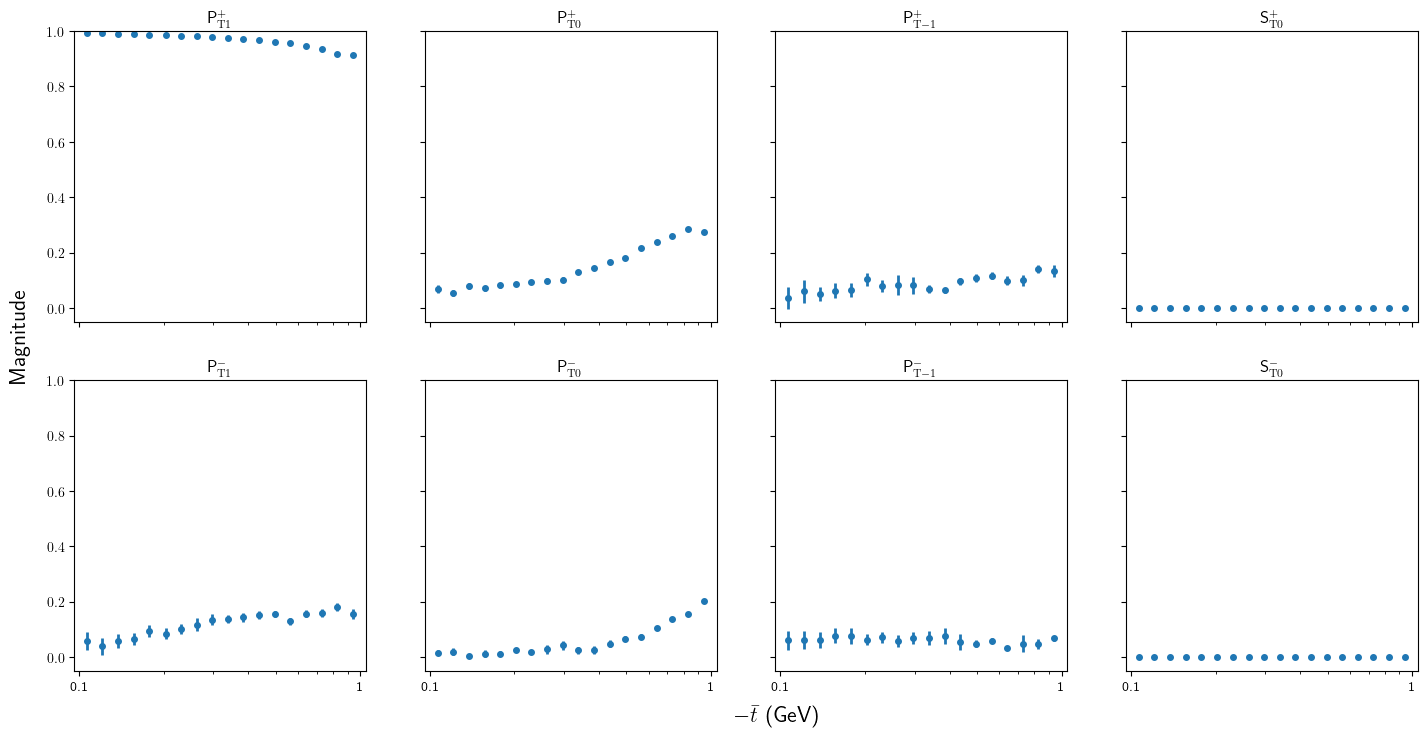

In [27]:
cols_mag = ["a_T_1_1", "a_T_1_0", "a_T_1_m1", "a_T_0_0",
        "b_T_1_1", "b_T_1_0", "b_T_1_m1", "b_T_0_0",
        "a_L_1_1", "a_L_1_0", "a_L_1_m1", "a_L_0_0",
        "b_L_1_1", "b_L_1_0", "b_L_1_m1", "b_L_0_0"]

cols_phase = ["aphi_T_1_1", "aphi_T_1_0", "aphi_T_1_m1", "aphi_T_0_0",
        "bphi_T_1_1", "bphi_T_1_0", "bphi_T_1_m1", "bphi_T_0_0",
        "aphi_L_1_1", "aphi_L_1_0", "aphi_L_1_m1", "aphi_L_0_0",
        "bphi_L_1_1", "bphi_L_1_0", "bphi_L_1_m1", "bphi_L_0_0"]

t = np.array([
    0.107, 0.121, 0.138, 0.157, 0.178, 0.203,
    0.230, 0.262, 0.297, 0.338, 0.384, 0.436,
    0.496, 0.564, 0.640, 0.728, 0.827, 0.940
])

mags_array = np.empty((18,4,4))
err_array = np.empty((18,4,4))

N = 1000
# i is t bin
# j is aT bT aL bL
# k is 11, 10, 1-1 00
# For HERMEs data they are saved this way (4 Q2 bins)

for i in range(18):
    if i<=4:
        tname = "PartialWaves"
    else:
        tname = "toyFitResults"
    df = ROOT.RDataFrame(tname, "~/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles/gluex_bootstrap_"+str(i)+".root")

    mags = df.AsNumpy(columns=cols_mag)
    phases = df.AsNumpy(columns=cols_phase)

    for j in range(4):
        #The main plotting
        for k in range(4):
            y = mags[cols_mag[k + 4*j]]
            mean_y = np.mean(y)
            err_y = np.std(y)

            mags_array[i,j,k] = mean_y
            err_array[i,j,k] = err_y

fig = plt.figure(figsize=(16,8))
axs = fig.subplots(2,4,sharex=True, sharey=True)
for j in range(2):
    #The main plotting
    for k in range(4):

        print(err_array[:,j,k])
        axs[j,k].errorbar(t,mags_array[:,j,k],yerr=err_array[:,j,k], fmt='.', markersize=8, elinewidth=2)
        axs[j,k].axis(ymin = -0.05, ymax = 1)
        axs[j,k].set_xscale('log')
        title = ToWave(cols_mag[k + 4*j])
        axs[j,k].set_title(title, size =12)
        axs[j,k].xaxis.set_major_formatter('{x:g}')
        #axs[j,k].xaxis.set_minor_formatter('{x:g}')
        #axs[j,k].scatter(phases_array[:,j,k], t, s=9)

    # axs[j,0].set_ylabel("Magnitude")
    #         axs[j,1].set_ylabel("Imaginary")
    #         if (j==3):
    #             axs[j,0].set_xlabel("Phase")
    #             axs[j,1].set_xlabel("Real")
    #
    #
    #         axs[j,1].legend()
        # Maybe have an overall title giving more information?
#fig.suptitle("GlueX Amplitudes' Magnitude and Phase Scaling".format(t[i]), size=18)
fig.supylabel("Magnitude", size=16, x=0.02)
fig.supxlabel("$-\\bar{t}$ (GeV)", size=16)
fig.subplots_adjust(left=0.06, bottom=0.08)
#fig.tight_layout()
fig.savefig("GlueX_scaling.pdf", dpi=800, transparent=True, format= 'pdf')


In [ ]:
### Difference between Derek and Is

cols_mag = ["a_T_1_1", "a_T_1_0", "a_T_1_m1",
        "b_T_1_1", "b_T_1_0", "b_T_1_m1"]

cols_mag_bru = ["a_1_1", "a_1_0", "a_1_m1",
        "b_1_1", "b_1_0", "b_1_m1"]

cols_phase = ["aphi_T_1_1", "aphi_T_1_0", "aphi_T_1_m1",
        "bphi_T_1_1", "bphi_T_1_0", "bphi_T_1_m1"]

cols_phase_bru = ["aphi_1_1", "aphi_1_0", "aphi_1_m1",
        "bphi_1_1", "bphi_1_0", "bphi_1_m1"]

df = ROOT.RDataFrame("fitResults", "~/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles/gluex_results_15.root")
df2 = ROOT.RDataFrame("PartialWaves", "~/Downloads/resultsRhoFixS.root")

df2 = df2.Define("aphi_1_1", "0")
df2 = df2.Define("bphi_1_1", "0")

min_log = df.Min("log_val").GetValue()
min_log2 = df2.Min("log_val").GetValue()

df = df.Filter("log_val<="+str(min_log+5))
df2 = df2.Filter("log_val<="+str(min_log2+1))

log_val = df.AsNumpy(["log_val"])
log_val2 = df2.AsNumpy(["log_val"])

N = log_val["log_val"].shape[0]
N2 = log_val2["log_val"].shape[0]

mags_array = np.empty((2,3))
err_array = np.empty((2,3))

mags = df.AsNumpy(columns=cols_mag)
phases = df.AsNumpy(columns=cols_phase)

mags2 = df2.AsNumpy(columns=cols_mag_bru)
phases2 = df2.AsNumpy(columns=cols_phase_bru)

for j in range(2):
    #The main plotting
    for k in range(3):
        y = np.mean(mags[cols_mag[k + 3*j]])
        y2 = np.mean(mags2[cols_mag_bru[k + 3*j]])
        
        diff_y = np.abs(y-y2)
        
        x = np.mean(phases[cols_phase[k + 3*j]])
        x2 = np.mean(phases2[cols_phase_bru[k + 3*j]])
        
        diff_x = np.abs(x-x2)
        
        print("The absolute difference between {0} and {1} is {2:.5f}, for {3} and {4} it is {5:.5f}.\nFor this their respective logchi2 ranges are [{6:.5f},{7:.5f}] and [{8:.5f},{9:.5f}].\n".format(cols_mag[k + 3*j],cols_mag_bru[k + 3*j],diff_y,cols_phase[k + 3*j],cols_phase_bru[k + 3*j],diff_x,log_val["log_val"].min(),log_val["log_val"].max(), log_val2["log_val"].min(),log_val2["log_val"].max()))
## Do same as abive, just make a list of the col names, iterate over then take difference and plot



In [ ]:
df = ROOT.RDataFrame("fitResults", "~/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles/GlueX_results15.root")
df2 = ROOT.RDataFrame("PartialWaves", "~/Desktop/PhD/Electroproduction/brufit/tutorials/PhotoAmps/TwoSpin0AmpsFromMoments/resultsGivenMomentsNoH3.root")

min_log = df.Min("log_val").GetValue()
df = df.Filter("log_val<="+str(min_log))
amp11 = df.Mean("a_T_1_1").GetValue()
bmp11 = df.Mean("b_T_1_1").GetValue()
amp10 = df.Mean("a_T_1_0").GetValue()
bmp10 = df.Mean("b_T_1_0").GetValue()
amp1m1 = df.Mean("a_T_1_m1").GetValue()
bmp1m1 = df.Mean("b_T_1_m1").GetValue()

aphi11 = df.Mean("aphi_T_1_1").GetValue()
bphi11 = df.Mean("bphi_T_1_1").GetValue()
aphi10 = df.Mean("aphi_T_1_0").GetValue()
bphi10 = df.Mean("bphi_T_1_0").GetValue()
aphi1m1 = df.Mean("aphi_T_1_m1").GetValue()
bphim1 = df.Mean("bphi_T_1_m1").GetValue()

min_log2 = df2.Min("log_val").GetValue()
df2 = df2.Filter("log_val<="+str(min_log))
ampbru11 = df2.Mean("a_1_1").GetValue()
bmpbru11 = df2.Mean("b_1_1").GetValue()
ampbru10 = df2.Mean("a_1_0").GetValue()
bmpbru10 = df2.Mean("b_1_0").GetValue()
ampbru1m1 = df2.Mean("a_1_m1").GetValue()
bmpbru1m1 = df2.Mean("b_1_m1").GetValue()

aphibru11 = 0
bphibru11 = 0
aphibru10 = df2.Mean("aphi_1_0").GetValue()
bphibru10 = df2.Mean("bphi_1_0").GetValue()
aphibru1m1 = df2.Mean("aphi_1_m1").GetValue()
bphibrum1 = df2.Mean("bphi_1_m1").GetValue()

print("me gives {} and {}".format(amp11, bmp11))
print("bru gives {} and {}".format(ampbru11, bmpbru11))